In [20]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

load_dotenv()

True

In [21]:
llm = ChatOpenAI()

In [22]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explaination: str

In [23]:
def generate_joke(state: JokeState):
    topic = state['topic']
    prompt = f"Generate a joke on the below topic:\n\nTopic: {topic}"

    response = llm.invoke(prompt).content

    return {'joke': response}

def explain_joke(state: JokeState):
    joke = state['joke']
    prompt = f"Explain the belwo joke:\n\nJoke: {joke}"

    response = llm.invoke(prompt).content

    return {"explaination": response}

In [24]:
graph = StateGraph(JokeState)

graph.add_node("generate_joke", generate_joke)
graph.add_node("explain_joke", explain_joke)

graph.add_edge(START, "generate_joke")
graph.add_edge("generate_joke", "explain_joke")
graph.add_edge("explain_joke", END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer = checkpointer)

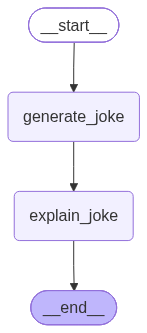

In [25]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [26]:
config1 = {"configurable": {"thread_id": 1}}
initial_state = {"topic": "pizza"}

workflow.invoke(initial_state, config=config1)

{'topic': 'pizza',
 'joke': 'Why did the pizza go to the doctor?\nBecause it was feeling a little saucy!',
 'explaination': 'This joke is a play on words. When someone is described as feeling "saucy," it means they are acting sassy or cheeky. In this case, the pizza went to the doctor because it was feeling saucy, both in the sense of having too much sauce and also acting cheeky.'}

In [27]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the doctor?\nBecause it was feeling a little saucy!', 'explaination': 'This joke is a play on words. When someone is described as feeling "saucy," it means they are acting sassy or cheeky. In this case, the pizza went to the doctor because it was feeling saucy, both in the sense of having too much sauce and also acting cheeky.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1996f7-48c1-6c27-8002-81623f154470'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-16T12:39:00.095393+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1996f7-3c1a-6b9f-8001-1a139f4360ea'}}, tasks=(), interrupts=())

In [28]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the doctor?\nBecause it was feeling a little saucy!', 'explaination': 'This joke is a play on words. When someone is described as feeling "saucy," it means they are acting sassy or cheeky. In this case, the pizza went to the doctor because it was feeling saucy, both in the sense of having too much sauce and also acting cheeky.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1996f7-48c1-6c27-8002-81623f154470'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-16T12:39:00.095393+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1996f7-3c1a-6b9f-8001-1a139f4360ea'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the doctor?\nBecause it was feeling a little saucy!'}, next=('explain_joke',), config={'configurable': {'thread_id': '1', 'checkpo

In [29]:
config2 = {'configurable': {"thread_id": 2}}
initial_state2 = {"topic": "pasta"}

workflow.invoke(initial_state2, config=config2)

{'topic': 'pasta',
 'joke': 'Why did the penne blush? Because it saw the spaghetti strap!',
 'explaination': 'This joke is a play on words. In this context, "blush" means to turn red in the face out of embarrassment or shyness. Penne and spaghetti are both types of pasta, and "strap" in this joke refers to the shoulder strap of a piece of clothing. The joke is funny because it creates a silly, fictional scenario where the penne pasta is embarrassed after seeing the spaghetti pasta wearing a shoulder strap, causing it to blush.'}

In [30]:
workflow.get_state(config = config2)

StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the penne blush? Because it saw the spaghetti strap!', 'explaination': 'This joke is a play on words. In this context, "blush" means to turn red in the face out of embarrassment or shyness. Penne and spaghetti are both types of pasta, and "strap" in this joke refers to the shoulder strap of a piece of clothing. The joke is funny because it creates a silly, fictional scenario where the penne pasta is embarrassed after seeing the spaghetti pasta wearing a shoulder strap, causing it to blush.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1996f7-7360-67e2-8002-3314233a774d'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-16T12:39:04.564498+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1996f7-5f6e-6357-8001-443f7d9855cc'}}, tasks=(), interrupts=())

In [31]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the penne blush? Because it saw the spaghetti strap!', 'explaination': 'This joke is a play on words. In this context, "blush" means to turn red in the face out of embarrassment or shyness. Penne and spaghetti are both types of pasta, and "strap" in this joke refers to the shoulder strap of a piece of clothing. The joke is funny because it creates a silly, fictional scenario where the penne pasta is embarrassed after seeing the spaghetti pasta wearing a shoulder strap, causing it to blush.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1996f7-7360-67e2-8002-3314233a774d'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-16T12:39:04.564498+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1996f7-5f6e-6357-8001-443f7d9855cc'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'pasta', 'joke': 'Why 

### Timetravel

In [36]:
workflow.get_state(config = {'configurable': {"thread_id": 2, "checkpoint_id": "1f1996f7-4a32-690c-8000-c07481fc59c6"}})

StateSnapshot(values={'topic': 'pasta'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_id': '1f1996f7-4a32-690c-8000-c07481fc59c6'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-08-16T12:39:00.246525+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1996f7-4a27-6040-bfff-30de2ed88070'}}, tasks=(PregelTask(id='04714eec-bffb-682d-0560-5edbbcf19bc3', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the penne blush? Because it saw the spaghetti strap!'}),), interrupts=())

In [37]:
workflow.invoke(None, config = {'configurable': {"thread_id": 2, "checkpoint_id": "1f1996f7-4a32-690c-8000-c07481fc59c6"}})

{'topic': 'pasta',
 'joke': 'Why did the pasta go to the doctor?\n\nBecause it was feeling al dente!',
 'explaination': 'This joke is a play on words. "Al dente" is an Italian term used to describe pasta that is cooked to be firm to the bite, but not overcooked. In this joke, the pasta is "feeling al dente" because it is not feeling well and needs to see a doctor. The humor comes from the pun on the phrase "feeling al dente."'}

In [41]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the pasta go to the doctor?\n\nBecause it was feeling al dente!', 'explaination': 'This joke is a play on words. "Al dente" is an Italian term used to describe pasta that is cooked to be firm to the bite, but not overcooked. In this joke, the pasta is "feeling al dente" because it is not feeling well and needs to see a doctor. The humor comes from the pun on the phrase "feeling al dente."'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1996fc-9f99-668e-8003-ab9e379b906e'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-08-16T12:41:23.419247+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1996fc-8ee9-6d4b-8002-d92f425da49f'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the pasta go to the doctor?\n\nBecause it was feeling al dente!'}, next=('explain_joke',), config={

Updating State

In [43]:
workflow.update_state(config = {'configurable': {"thread_id": 2, "checkpoint_id": "1f1996f7-4a32-690c-8000-c07481fc59c6", "checkpoint_ns": ""}}, values={'topic': "samosa"})

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f19970a-5efd-6290-8001-603b15146ef5'}}

In [45]:
list(workflow.get_state_history(config = config2))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f19970a-5efd-6290-8001-603b15146ef5'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-08-16T12:47:32.454011+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1996f7-4a32-690c-8000-c07481fc59c6'}}, tasks=(PregelTask(id='b1d09c74-5a33-4227-26e4-c74217efdd3d', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the pasta go to the doctor?\n\nBecause it was feeling al dente!', 'explaination': 'This joke is a play on words. "Al dente" is an Italian term used to describe pasta that is cooked to be firm to the bite, but not overcooked. In this joke, the pasta is "feeling al dente" because it is not feeling well and needs to see a d

In [47]:
workflow.invoke(None, config={'configurable': {"thread_id": 2, "checkpoint_id": "1f19970a-5efd-6290-8001-603b15146ef5"}})

{'topic': 'samosa',
 'joke': 'Why did the samosa go to the party?\n\nBecause it wanted to meet its fillings!',
 'explaination': 'This joke plays on the double meaning of "fillings." In the context of a samosa, fillings refer to the ingredients inside the pastry. However, "fillings" can also refer to the people attending a social event or party. So, in the joke, the samosa went to the party to meet its own fillings (ingredients) as if they were guests at the party.'}